In [1]:
from azureml.core import Workspace, Dataset, Datastore

subscription_id = 'f8c5aac3-29fc-4387-858a-1f61722fb57a'
resource_group = 'forskerpl-n0ybkr-rg'
workspace_name = 'forskerpl-n0ybkr-mlw'

workspace = Workspace(subscription_id, resource_group, workspace_name)
datastore = Datastore.get(workspace, "researcher_data")

# تعریف Dataset از مسیر
dataset = Dataset.File.from_files(path=(datastore,'Zahra/032026/CoreBehrt_OOT/MDPS/3_Holdout/ARF/Predictions'))

# گرفتن لیست فایل‌ها
file_paths = dataset.to_path()

# نمایش
for path in file_paths:
    print(path)


Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


Resolving access token for scope "https://storage.azure.com/.default" using identity of type "MANAGED".
Getting data access token with Assigned Identity (client_id=clientid) and endpoint type based on configuration
{'infer_column_types': 'False', 'activity': 'to_path'}
{'infer_column_types': 'False', 'activity': 'to_path', 'activityApp': 'FileDataset'}
/evaluate_finetune.yaml
/finetune_config.yaml
/metrics.csv
/predictions.csv
/embeddings/fold_5/cls_embeddings.pt
/embeddings/fold_5/pids.pt
/embeddings/fold_2/cls_embeddings.pt
/embeddings/fold_2/pids.pt
/embeddings/fold_4/cls_embeddings.pt
/embeddings/fold_4/pids.pt
/embeddings/fold_1/cls_embeddings.pt
/embeddings/fold_1/pids.pt
/embeddings/fold_3/cls_embeddings.pt
/embeddings/fold_3/pids.pt


In [2]:
import numpy as np

# ---------- Midrank ----------
def compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)

    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j

    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2


# ---------- Fast DeLong ----------
def fastDeLong(predictions_sorted_transposed, label_1_count):
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m

    pos_scores = predictions_sorted_transposed[:, :m]
    neg_scores = predictions_sorted_transposed[:, m:]

    k = predictions_sorted_transposed.shape[0]

    tx = np.empty([k, m], dtype=float)
    ty = np.empty([k, n], dtype=float)
    tz = np.empty([k, m + n], dtype=float)

    for r in range(k):
        tx[r] = compute_midrank(pos_scores[r])
        ty[r] = compute_midrank(neg_scores[r])
        tz[r] = compute_midrank(predictions_sorted_transposed[r])

    aucs = tx.sum(axis=1) / (m * n) - (m + 1.) / (2. * n)

    v01 = (tz[:, :m] - tx) / n
    v10 = (tz[:, m:] - ty) / m

    sx = np.cov(v01)
    sy = np.cov(v10)

    delongcov = sx / m + sy / n

    return aucs, delongcov


# ---------- AUC + STD via DeLong ----------
def delong_roc_variance(y_true, y_pred):

    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred)

    assert set(np.unique(y_true)) == {0,1}

    # مرتب‌سازی بر اساس label (مثبت‌ها اول)
    order = np.argsort(-y_true)
    y_true = y_true[order]
    y_pred = y_pred[order]

    label_1_count = int(np.sum(y_true))

    preds = y_pred.reshape(1, -1)

    aucs, delongcov = fastDeLong(preds, label_1_count)

    auc = aucs[0]

    # اگر covariance scalar بود
    auc_var = delongcov if np.ndim(delongcov) == 0 else delongcov[0,0]

    auc_std = np.sqrt(auc_var)

    return auc, auc_std

from sklearn.metrics import roc_auc_score
import numpy as np

def bootstrap_auc(y_true, y_score, n_bootstraps=2000, random_seed=42):

    rng = np.random.RandomState(random_seed)
    bootstrapped_scores = []

    y_true = np.array(y_true)
    y_score = np.array(y_score)

    for i in range(n_bootstraps):
        indices = rng.randint(0, len(y_score), len(y_score))
        if len(np.unique(y_true[indices])) < 2:
            continue

        score = roc_auc_score(y_true[indices], y_score[indices])
        bootstrapped_scores.append(score)

    sorted_scores = np.sort(bootstrapped_scores)

    auc_mean = roc_auc_score(y_true, y_score)
    ci_lower = sorted_scores[int(0.025 * len(sorted_scores))]
    ci_upper = sorted_scores[int(0.975 * len(sorted_scores))]
    auc_std = np.std(sorted_scores)

    return auc_mean, auc_std, ci_lower, ci_upper


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


def plot_cv_roc(df, experiment_name, outcome_name, save_path=None):

    fold_cols = [
        "fold_1_probas",
        "fold_2_probas",
        "fold_3_probas",
        "fold_4_probas",
        "fold_5_probas"
    ]

    y_true = df["target"].astype(int)

    mean_fpr = np.linspace(0, 1, 300)
    tprs = []
    aucs = []

    plt.figure(figsize=(7, 6))
    colors = plt.cm.tab10.colors

    for i, col in enumerate(fold_cols):

        y_score = df[col]

        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)

        aucs.append(roc_auc)

        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0
        tprs.append(interp_tpr)

        plt.plot(
            fpr,
            tpr,
            color=colors[i],
            lw=1.5,
            alpha=0.8,
            label=f"Fold {i+1} (AUC = {roc_auc:.3f})"
        )

    # Mean ROC
    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    mean_tpr[-1] = 1.0

    plt.plot(
        mean_fpr,
        mean_tpr,
        color="black",
        lw=2.5,
        label=f"Mean ROC (AUC = {mean_auc:.3f} ± {std_auc:.3f})"
    )

    plt.fill_between(
        mean_fpr,
        np.maximum(mean_tpr - std_tpr, 0),
        np.minimum(mean_tpr + std_tpr, 1),
        color="grey",
        alpha=0.2,
        label="±1 SD"
    )

    # Random baseline
    plt.plot([0, 1], [0, 1], linestyle="--", color="grey", lw=1)

    plt.xlim([0, 1])
    plt.ylim([0, 1.05])

    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)
    

    plt.title(
        f"ROC Curve for {outcome_name} Prediction ({experiment_name})",
        fontsize=13
    )

    plt.legend(loc="lower right", frameon=True)
    plt.grid(alpha=0.25)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}


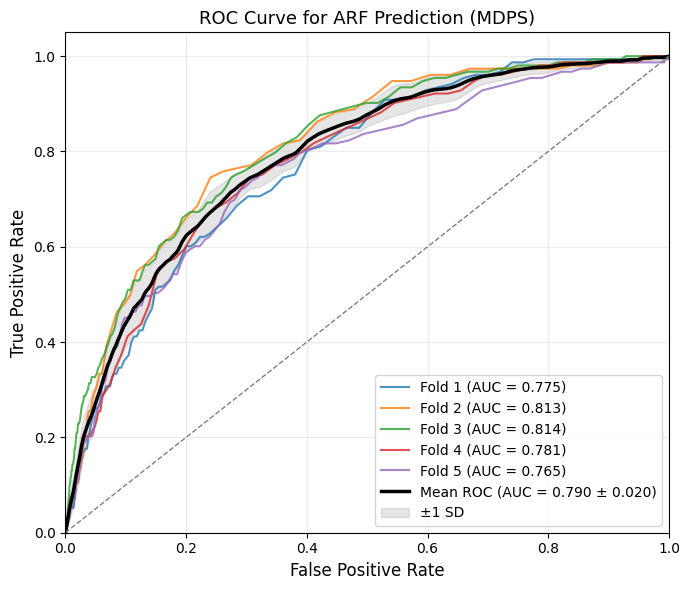

In [4]:
datastore = Datastore.get(workspace, "researcher_data")
dataset = Dataset.Tabular.from_delimited_files(
    path=(datastore, 'Zahra/032026/CoreBehrt_OOT/MDPS/3_Holdout/ARF/Predictions/predictions.csv')
)


# تبدیل Dataset به DataFrame
df_MDPS = dataset.to_pandas_dataframe()
plot_cv_roc(df_MDPS, "MDPS", "ARF")

In [5]:
df_MDPS

,pid,target,sequence_length,fold_1_probas,fold_2_probas,fold_3_probas,fold_4_probas,fold_5_probas
0,12,False,239,0.013637,0.009708,0.016403,0.006693,0.018833
1,1615,False,296,0.028436,0.012054,0.021948,0.014957,0.027585
2,1760,False,32,0.014504,0.015425,0.016915,0.010653,0.031619
3,2071,False,512,0.022977,0.009708,0.014064,0.013637,0.013637
4,2272,False,65,0.018833,0.006904,0.009126,0.007577,0.019419
...,...,...,...,...,...,...,...,...
97291,2215454,False,512,0.015906,0.019419,0.048137,0.011332,0.028008
97292,2215775,False,188,0.013223,0.008316,0.016403,0.007121,0.020023
97293,2216067,False,85,0.007577,0.008062,0.012432,0.006488,0.017986
97294,2216162,False,7,0.025565,0.009413,0.018547,0.008577,0.024423


In [6]:
print("MDPS:")
print(df_MDPS["target"].value_counts())

print("\nMDS:")
print(df_MDS["target"].value_counts())

MDPS:
False    97143
True       153
Name: target, dtype: int64

MDS:


NameError: name 'df_MDS' is not defined

In [ ]:
df_MDS

In [10]:
dataset = Dataset.Tabular.from_delimited_files(
    path=(datastore, 'Zahra/032026/CoreBehrt_OOT/MDS/3_Holdout/ARF/Predictions/predictions.csv')
)

# تبدیل Dataset به DataFrame
df_MDS = dataset.to_pandas_dataframe()
plot_cv_roc(df_MDS, "MDS", "Mortality")

2026-04-04 21:27:41.780566 | ActivityCompleted: Activity=from_delimited_files, HowEnded=Failure, Duration=150.01 [ms], Info = {'activity_id': '10a3e0dc-df4d-45b1-b059-b5a508271d89', 'activity_name': 'from_delimited_files', 'activity_type': 'PublicApi', 'app_name': 'TabularDataset', 'source': 'azureml.dataset', 'version': '1.60.0', 'dataprepVersion': '5.1.6', 'sparkVersion': '', 'subscription': '', 'run_id': '', 'resource_group': '', 'workspace_name': '', 'experiment_id': '', 'location': '', 'completionStatus': 'Success', 'durationMs': 0.06}, Exception=DatasetValidationError; DatasetValidationError:
	Message: Failed to validate the data.If data is inaccessible, please set validate to False.
The requested stream was not found. Please make sure the request uri is correct.| session_id=l_50d6450b-c873-40d5-9d31-8537058d7fe6
	InnerException None
	ErrorResponse 
{
    "error": {
        "code": "UserError",
        "message": "Failed to validate the data.If data is inaccessible, please set va

DatasetValidationError: DatasetValidationError:
	Message: Failed to validate the data.If data is inaccessible, please set validate to False.
The requested stream was not found. Please make sure the request uri is correct.| session_id=l_50d6450b-c873-40d5-9d31-8537058d7fe6
	InnerException None
	ErrorResponse 
{
    "error": {
        "code": "UserError",
        "message": "Failed to validate the data.If data is inaccessible, please set validate to False.\nThe requested stream was not found. Please make sure the request uri is correct.| session_id=l_50d6450b-c873-40d5-9d31-8537058d7fe6"
    }
}

In [ ]:

dataset = Dataset.Tabular.from_delimited_files(
    path=(datastore, 'Zahra/022026/CoreBehrt_CV/MDP/3_Heldout/Mortality/Evaluation2/predictions.csv')
)

# تبدیل Dataset به DataFrame
df_MDP = dataset.to_pandas_dataframe()
plot_cv_roc(df_MDP, "MDP", "Mortality")

In [ ]:
dataset = Dataset.Tabular.from_delimited_files(
    path=(datastore, 'Zahra/022026/CoreBehrt_CV/MD/3_Heldout/Mortality/Evaluation2/predictions.csv')
)

# تبدیل Dataset به DataFrame
df_MD = dataset.to_pandas_dataframe()
plot_cv_roc(df_MD, "MD", "Mortality")